# Scientific evidence on biodiversity loss is rapidly expanding

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis import time_development
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
TEMPORAL_CONFIG = RESULTS_CONFIG["temporal_development"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
THREAT_ORDER, THREAT_COLORS, THREAT_DISPLAY_NAMES = (
    results_config.threat_l0_display(RESULTS_CONFIG)
)
THREAT_STACK_ORDER = results_config.threat_l0_stack_order(RESULTS_CONFIG)
THREAT_CODES, THREAT_FAMILIES, STACK_SORT_COLORS = (
    results_config.threat_l0_temporal_display(RESULTS_CONFIG)
)

START_YEAR = TEMPORAL_CONFIG["analysis_start_year"]
END_YEAR = TEMPORAL_CONFIG["analysis_end_year"]
ROLLING_YEARS = TEMPORAL_CONFIG["rolling_cagr_years"]
FOCAL_THREAT = TEMPORAL_CONFIG["focal_threat"]
POLICY_EVENTS = [
    (
        event["year"],
        event["description"],
        event["text_y"],
        event["horizontal_alignment"],
        event["x_offset"],
    )
    for event in TEMPORAL_CONFIG["policy_events"]
]

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

OUTPUT_DIR = PROJECT_ROOT / TEMPORAL_CONFIG["output_directory"]
TABLE_DIR = OUTPUT_DIR / TEMPORAL_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / TEMPORAL_CONFIG["figure_subdirectory"]
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Provenance: the complete set of inputs this result depends on.
status = "found" if CORPUS_DIR.exists() else "MISSING"
print(f"Input   dataset  {CORPUS_DIR.relative_to(PROJECT_ROOT)}  [{status}]")
if not CORPUS_DIR.exists():
    raise FileNotFoundError(
        "Run notebooks/data_processing/04_dataset.ipynb first."
    )
print(f"Output section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


Input   dataset  notebooks/data_processing/outputs/04_dataset  [found]
Output section: notebooks/results/outputs/01_evidence_growth


## 1. Preview of temporal tables

- Only eligible records where `s2_dir == "negative"` are considered for this analysis 
- Threat table's grain is `UT × publication_year × threat`. A publication assigned to `k` distinct threats contributes `1/k` to each, so its total weight per year is 1.

In [5]:
corpus_df = evidence_corpus_prep.BiodiversityEvidenceStore(CORPUS_DIR).load(
    columns=["UT", "s2_dir", "publication_year", "pred_threat_l0"]
).publications

loss_df, threat_long_df, evidence_audit_df = time_development.prepare_loss_evidence(
    corpus_df, START_YEAR, END_YEAR, TEMPORAL_CONFIG["threat_order"]
)
annual_counts, annual_table = time_development.annual_publication_tables(
    loss_df, START_YEAR, END_YEAR
)
(
    threat_fractional_counts_df,
    threat_shares_df,
    composition_long_df,
    composition_audit_df,
) = time_development.threat_composition_tables(
    threat_long_df,
    annual_counts,
    TEMPORAL_CONFIG["threat_order"],
    START_YEAR,
    END_YEAR,
)
threat_order = list(threat_fractional_counts_df.columns)
(
    cagr_detailed_df,
    cagr_matrix_df,
    rolling_all_df,
    rolling_threat_df,
    overall_rolling_cagr,
) = time_development.growth_tables(
    threat_fractional_counts_df,
    annual_counts,
    threat_order,
    THREAT_CODES,
    TEMPORAL_CONFIG["cagr_periods"],
    ROLLING_YEARS,
    START_YEAR,
    END_YEAR,
)
stack_order = [
    threat for threat in THREAT_STACK_ORDER if threat in threat_shares_df.columns
]
overall_cagr = time_development.cagr_pct(
    int(annual_counts.loc[START_YEAR]),
    int(annual_counts.loc[END_YEAR]),
    END_YEAR - START_YEAR,
)

display(evidence_audit_df.style.format({"value": "{:,}"}).hide(axis="index"))
endpoint_summary_df = pd.DataFrame(
    {
        "threat": threat_order,
        "share_2000_pct": threat_shares_df.loc[START_YEAR, threat_order].to_numpy(),
        "share_2025_pct": threat_shares_df.loc[END_YEAR, threat_order].to_numpy(),
        "change_pp": (
            threat_shares_df.loc[END_YEAR, threat_order]
            - threat_shares_df.loc[START_YEAR, threat_order]
        ).to_numpy(),
        "cagr_2000_2025_pct": cagr_matrix_df[f"{START_YEAR}-{END_YEAR}"].to_numpy(),
    }
)
display(
    endpoint_summary_df.assign(magnitude=endpoint_summary_df["change_pp"].abs())
    .nlargest(6, "magnitude")
    .drop(columns="magnitude")
    .round(2)
)
print(
    f"{START_YEAR}: {int(annual_counts.loc[START_YEAR]):,} publications; "
    f"{END_YEAR}: {int(annual_counts.loc[END_YEAR]):,}; "
    f"complete-year total {int(annual_counts.sum()):,}; "
    f"overall CAGR {overall_cagr:.2f}%"
)

metric,value
Eligible publications,"605,199"
Biodiversity-loss publications,"253,081"
Loss publications in 2000–2025,"245,168"
Loss publications outside window or missing year,"7,913"
In-window publications without usable threat,0
Unique document–threat assignments,"315,636"
Observed threat classes,12


,threat,share_2000_pct,share_2025_pct,change_pp,cagr_2000_2025_pct
9,Climate Change & Severe Weather,4.90,19.54,14.64,14.92
8,Pollution,40.45,32.51,-7.94,7.79
4,Biological Resource Use,11.25,5.89,-5.36,5.95
0,Residential & Commercial Development,1.86,5.68,3.82,13.70
6,Natural System Modifications,7.65,5.40,-2.24,7.23
11,Unclear,6.88,5.54,-1.34,7.80


2000: 2,530 publications; 2025: 20,520; complete-year total 245,168; overall CAGR 8.73%


## 2. The manuscript figure

`combined-time-development.pdf` — Figure `time_development` in the paper. Three panels on
one shared 2000–2025 axis:

- **(a)**~Annual number of scientific articles for complete publication years from 2000 to 2025 ($n = 245{,}168$). Selected international biodiversity-policy and assessment milestones are shown for context. 
- **(b)**~Annual distribution of broad threat categories from the International Union for Conservation of Nature (IUCN) Threats Classification Scheme. A publication assigned to $k$ threats contributes $1/k$ to each, so every publication contributes one unit in total per year. 
- **(c)**~~Rolling five-year Compound Annual Growth rate (CAGR), using unique-publication counts overall and fractionally weighted publication counts for each broad threat category.

Only complete publication years 2000–2025 are analyzed. `Other Options` and `Unclear`
stay in the exported tables but are omitted from panel c.

In [6]:
BAR_GREY, LINE_COLOR = "#9A9A9A", "#7A7A7A"
Y_TICKS = [0, 5000, 10000, 15000, 20000, 25000]
BAND_TOP = Y_TICKS[-1]

bar_years = annual_table["publication_year"].to_numpy()
bar_counts = annual_table["n_publications"].to_numpy()
count_by_year = dict(zip(bar_years, bar_counts))

composition_years = threat_shares_df.index.to_numpy()

excluded = set(TEMPORAL_CONFIG["growth_plot_excluded_threats"])
growth_plot_threats = [threat for threat in threat_order if threat not in excluded]
rolling_end_years = rolling_threat_df.index.to_numpy()
plotted_values = rolling_threat_df[growth_plot_threats].to_numpy()
y_min = min(0, int(np.floor(np.nanmin(plotted_values) / 5) * 5))
y_max = max(5, int(np.ceil(np.nanmax(plotted_values) / 5) * 5))

assert bar_years[0] == START_YEAR and bar_years[-1] == END_YEAR, (
    "Panel a must cover exactly the complete years the caption commits to."
)
print(f"Panel a: {len(bar_years)} complete years; panel b: {len(stack_order)} threats")

Panel a: 26 complete years; panel b: 12 threats


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/combined_time_development.pdf


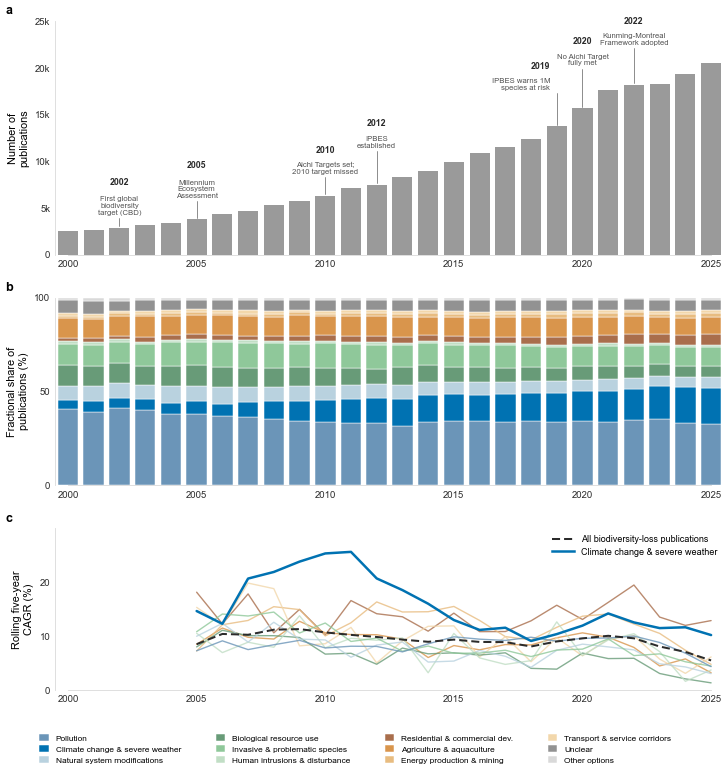

In [7]:
fig, (ax_a, ax_b, ax_c) = plt.subplots(
    3, 1, figsize=(7.6, 7.6), sharex=True,
    gridspec_kw={"height_ratios": [1.80, 1.45, 1.25]},
)
shared_year_ticks = [2000, 2005, 2010, 2015, 2020, 2025]

# A — complete-year publication volume and milestones.
ax_a.bar(
    bar_years, bar_counts, width=0.78,
    color=BAR_GREY, edgecolor="none", zorder=2,
)
description_size = 5.6
description_line_points = description_size * 1.12
for year, description, text_y, alignment, offset in POLICY_EVENTS:
    text_x = year + offset
    ax_a.plot(
        [year, year], [count_by_year[year] + 150, text_y - 250],
        color=LINE_COLOR, linewidth=0.6, zorder=3,
        solid_capstyle="round",
    )
    ax_a.text(
        text_x, text_y, description, ha=alignment, va="bottom",
        fontsize=description_size, color="#555555", linespacing=1.10,
    )
    ax_a.annotate(
        str(year), xy=(text_x, text_y),
        xytext=(
            0,
            (description.count("\n") + 1) * description_line_points + 2,
        ),
        textcoords="offset points", ha=alignment, va="bottom",
        fontsize=6.3, fontweight="bold", color=visualization.BIODIVERSITY["ink"],
    )
ax_a.set_ylim(0, BAND_TOP)
ax_a.set_yticks(Y_TICKS)
ax_a.yaxis.set_major_formatter(
    lambda value, _: f"{value / 1000:.0f}k" if value >= 1000 else f"{value:.0f}"
)
ax_a.set_ylabel("Number of\npublications", fontsize=7.8)

# B — annual threat composition.
bottoms = np.zeros(len(composition_years))
for threat in stack_order:
    values = threat_shares_df[threat].to_numpy()
    ax_b.bar(
        composition_years, values, bottom=bottoms, width=0.8,
        color=THREAT_COLORS[threat],
        edgecolor=visualization.BIODIVERSITY["paper"], linewidth=0.35, zorder=2,
    )
    bottoms += values
ax_b.set_ylim(0, 100)
ax_b.set_yticks([0, 50, 100])
ax_b.set_ylabel("Fractional share of\npublications (%)", fontsize=7.8)

# C — rolling five-year CAGR.
for threat in growth_plot_threats:
    focal = threat == FOCAL_THREAT
    ax_c.plot(
        rolling_end_years, rolling_threat_df[threat],
        color=THREAT_COLORS[threat],
        linewidth=1.8 if focal else 1.0,
        alpha=1.0 if focal else 0.80,
        solid_capstyle="round", zorder=3 if focal else 2,
    )
ax_c.plot(
    rolling_end_years, overall_rolling_cagr,
    color=visualization.BIODIVERSITY["ink"], linewidth=1.45,
    linestyle=(0, (4, 2)), zorder=4,
)
ax_c.set_ylim(y_min, y_max)
ax_c.set_yticks([0, 10, 20])
ax_c.axhline(0, color=visualization.BIODIVERSITY["neutral"], linewidth=0.6, zorder=0)
ax_c.set_ylabel("Rolling five-year\nCAGR (%)", fontsize=7.8)
ax_c.legend(
    handles=[
        Line2D(
            [0], [0], color=visualization.BIODIVERSITY["ink"], linewidth=1.45,
            linestyle=(0, (4, 2)),
            label="All biodiversity-loss publications",
        ),
        Line2D(
            [0], [0], color=THREAT_COLORS[FOCAL_THREAT], linewidth=1.8,
            label="Climate change & severe weather",
        ),
    ],
    loc="upper right", frameon=False, fontsize=6.5,
    handlelength=2.4, labelspacing=0.4, borderaxespad=0.35,
)

for label, axis in zip("abc", (ax_a, ax_b, ax_c)):
    axis.text(
        -0.075, 1.02, label, transform=axis.transAxes,
        fontsize=9.0, fontweight="bold", va="bottom",
    )
    axis.spines[["top", "right"]].set_visible(False)
    axis.spines[["left", "bottom"]].set_color(visualization.BIODIVERSITY["neutral"])
    axis.spines[["left", "bottom"]].set_linewidth(0.6)
    axis.tick_params(
        length=0, colors=visualization.BIODIVERSITY["ink"],
        labelsize=6.8, labelbottom=True,
    )
    axis.grid(False)
    axis.set_xticks(shared_year_ticks)
    axis.spines["bottom"].set_bounds(START_YEAR, END_YEAR)
ax_a.spines["left"].set_bounds(0, BAND_TOP)
ax_b.spines["left"].set_bounds(0, 100)
ax_c.spines["left"].set_bounds(y_min, y_max)
ax_c.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)

fig.legend(
    handles=[
        Patch(
            facecolor=THREAT_COLORS[threat],
            edgecolor=visualization.BIODIVERSITY["paper"], linewidth=0.35,
            label=THREAT_DISPLAY_NAMES[threat],
        )
        for threat in stack_order
    ],
    loc="lower left", ncol=4, mode="expand",
    bbox_to_anchor=(0.08, 0.004, 0.84, 0.09),
    frameon=False, fontsize=6.0, handlelength=1.15,
    handleheight=0.9, columnspacing=1.1,
    labelspacing=0.45, borderaxespad=0.0,
)
fig.subplots_adjust(
    left=0.105, right=0.985, top=0.985,
    bottom=0.105, hspace=0.22,
)
visualization.save_figure(
    fig,
    FIGURE_DIR / TEMPORAL_CONFIG["combined_figure_filename"],
    formats=["pdf"],
    facecolor="white",
)
plt.show()

## 3. Export

In [8]:
for table, filename in (
    (evidence_audit_df, "evidence_audit"),
    (annual_table, "annual_publication_counts"),
    (threat_shares_df.reset_index(), "threat_year_shares"),
    (cagr_matrix_df.reset_index(), "threat_cagr_by_period"),
    (rolling_all_df.reset_index(), "rolling_five_year_cagr"),
):
    path = TABLE_DIR / f"{filename}.csv"
    table.to_csv(path, index=False)
    print(path.relative_to(PROJECT_ROOT))
for path in sorted(FIGURE_DIR.glob("*.pdf")):
    print(path.relative_to(PROJECT_ROOT))

manifest = {
    "result": "01_evidence_growth",
    "method_details": {
        "analysis_scope": {
            "years": f"{START_YEAR}-{END_YEAR} complete publication years",
            "n_years": int(len(annual_counts)),
            "n_publications": int(annual_counts.sum()),
        },
        "panel_a": {
            "grain": "one unique publication (UT) per publication year",
            "n_publications": int(annual_counts.sum()),
            f"n_{START_YEAR}": int(annual_counts.loc[START_YEAR]),
            f"n_{END_YEAR}": int(annual_counts.loc[END_YEAR]),
        },
        "panel_b": {
            "grain": "UT x publication_year x distinct threat",
            "n_publications": int(annual_counts.sum()),
            "n_publication_threat_assignments": int(len(threat_long_df)),
            "n_threat_classes": int(len(threat_order)),
            "fractional_weight_formula": (
                "w_i,t = 1 / k_i, where k_i is the number of distinct threats "
                "assigned to publication i; sum_t(w_i,t) = 1"
            ),
            "share_formula": (
                "share_t,y (%) = 100 * sum_i(w_i,t,y) / N_y, where N_y is the "
                "number of unique publications in year y"
            ),
        },
        "panel_c": {
            "analysis_n_publications": int(annual_counts.sum()),
            "n_plotted_threat_classes": int(len(growth_plot_threats)),
            "n_rolling_windows": int(len(rolling_end_years)),
            "rolling_window_years": int(ROLLING_YEARS),
            "overall_series": "annual unique-publication count",
            "threat_series": "annual sum of 1/k fractional publication weights",
            "cagr_formula": (
                "CAGR (%) = 100 * ((V_end / V_base) ** "
                "(1 / (end_year - base_year)) - 1)"
            ),
            "rolling_cagr_formula": (
                "CAGR_y (%) = 100 * ((V_y / V_(y-5)) ** (1 / 5) - 1)"
            ),
        },
    },
    "artifacts": {
        "csv/evidence_audit.csv": (
            "Counts retained at each evidence-selection step, including eligible "
            "records, biodiversity-loss records, complete-year coverage, and "
            "document-threat assignments."
        ),
        "csv/annual_publication_counts.csv": (
            "Annual unique biodiversity-loss publication counts for 2000-2025, "
            "with cumulative counts and year-on-year growth."
        ),
        "csv/threat_year_shares.csv": (
            "Annual fractional distribution of publications across broad IUCN threat "
            "categories; a publication assigned to k threats contributes 1/k to each."
        ),
        "csv/threat_cagr_by_period.csv": (
            "Compound annual growth rates of fractional publication counts for each "
            "broad threat category across the configured analysis periods."
        ),
        "csv/rolling_five_year_cagr.csv": (
            "Rolling five-year CAGR using unique-publication counts overall and "
            "fractional publication counts for each threat, indexed by window end year."
        ),
        "figures/combined_time_development.pdf": (
            "Three-panel figure showing annual publication volume, annual "
            "fractional threat shares, and rolling five-year CAGR."
        ),
    },
}
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2) + "\n", encoding="utf-8"
)
print(manifest_path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/01_evidence_growth/csv/evidence_audit.csv
notebooks/results/outputs/01_evidence_growth/csv/annual_publication_counts.csv
notebooks/results/outputs/01_evidence_growth/csv/threat_year_shares.csv
notebooks/results/outputs/01_evidence_growth/csv/threat_cagr_by_period.csv
notebooks/results/outputs/01_evidence_growth/csv/rolling_five_year_cagr.csv
notebooks/results/outputs/01_evidence_growth/figures/combined_time_development.pdf
notebooks/results/outputs/01_evidence_growth/manifest.json
